# 1. Import Modeling Data

In [41]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay, RocCurveDisplay

In [46]:
X_train = pd.read_csv('../Datasets/Modeling/X_train.csv')
X_val = pd.read_csv('../Datasets/Modeling/X_val.csv')
X_test = pd.read_csv('../Datasets/Modeling/X_test.csv')

y_train = pd.read_csv('../Datasets/Modeling/y_train.csv')
y_val = pd.read_csv('../Datasets/Modeling/y_val.csv')
y_test = pd.read_csv('../Datasets/Modeling/y_test.csv')

# 2. Data Preview

In [43]:
X_samples = [X_train, X_val, X_test]
y_samples = [y_train, y_val, y_test]

for X in X_samples:
    display(X.info())

for y in y_samples:
    display(y.info())

<class 'pandas.DataFrame'>
RangeIndex: 4930 entries, 0 to 4929
Data columns (total 57 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             4930 non-null   int64  
 1   Age                                4930 non-null   float64
 2   Under 30                           4930 non-null   int64  
 3   Senior Citizen                     4930 non-null   int64  
 4   Married                            4930 non-null   int64  
 5   Number of Dependents               4930 non-null   float64
 6   City                               4930 non-null   float64
 7   Zip Code                           4930 non-null   int64  
 8   Latitude                           4930 non-null   float64
 9   Longitude                          4930 non-null   float64
 10  Number of Referrals                4930 non-null   float64
 11  Tenure in Months                   4930 non-null   float64
 12  Pho

None

<class 'pandas.DataFrame'>
RangeIndex: 1056 entries, 0 to 1055
Data columns (total 57 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             1056 non-null   int64  
 1   Age                                1056 non-null   float64
 2   Under 30                           1056 non-null   int64  
 3   Senior Citizen                     1056 non-null   int64  
 4   Married                            1056 non-null   int64  
 5   Number of Dependents               1056 non-null   float64
 6   City                               1056 non-null   float64
 7   Zip Code                           1056 non-null   int64  
 8   Latitude                           1056 non-null   float64
 9   Longitude                          1056 non-null   float64
 10  Number of Referrals                1056 non-null   float64
 11  Tenure in Months                   1056 non-null   float64
 12  Pho

None

<class 'pandas.DataFrame'>
RangeIndex: 1057 entries, 0 to 1056
Data columns (total 57 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             1057 non-null   int64  
 1   Age                                1057 non-null   float64
 2   Under 30                           1057 non-null   int64  
 3   Senior Citizen                     1057 non-null   int64  
 4   Married                            1057 non-null   int64  
 5   Number of Dependents               1057 non-null   float64
 6   City                               1057 non-null   float64
 7   Zip Code                           1057 non-null   int64  
 8   Latitude                           1057 non-null   float64
 9   Longitude                          1057 non-null   float64
 10  Number of Referrals                1057 non-null   float64
 11  Tenure in Months                   1057 non-null   float64
 12  Pho

...

None

<class 'pandas.DataFrame'>
RangeIndex: 1056 entries, 0 to 1055
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Churn Label  1056 non-null   int64
dtypes: int64(1)
memory usage: 8.4 KB


None

<class 'pandas.DataFrame'>
RangeIndex: 1057 entries, 0 to 1056
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Churn Label  1057 non-null   int64
dtypes: int64(1)
memory usage: 8.4 KB


None

# 3. Training Baseline Model

In [47]:
lr = LogisticRegression(class_weight='balanced', random_state=42, verbose=0)
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
lgb = LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1)
xgb = XGBClassifier(scale_pos_weight=float(np.sum(y_train == 0)) / np.sum(y_train == 1), random_state=42, verbosity=0)
cb = CatBoostClassifier(auto_class_weights='Balanced', random_state=42, verbose=False)

models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'Lightgbm': lgb,
    'XGBoost': xgb,
    'CatBoost': cb
}

In [48]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'AUC': auc
    })

pd.DataFrame(results).sort_values(by='F1', ascending=False).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1,AUC
0,CatBoost,0.855251,0.695122,0.811388,0.748768,0.841261
1,Lightgbm,0.858089,0.707937,0.793594,0.748322,0.837519
2,Random Forest,0.858089,0.722034,0.758007,0.739583,0.826169
3,XGBoost,0.851466,0.708054,0.750890,0.728843,0.819388
4,Logistic Regression,0.723746,0.487179,0.743772,0.588732,0.730134


--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.91      0.86      0.89       776
           1       0.67      0.77      0.71       281

    accuracy                           0.84      1057
   macro avg       0.79      0.81      0.80      1057
weighted avg       0.85      0.84      0.84      1057



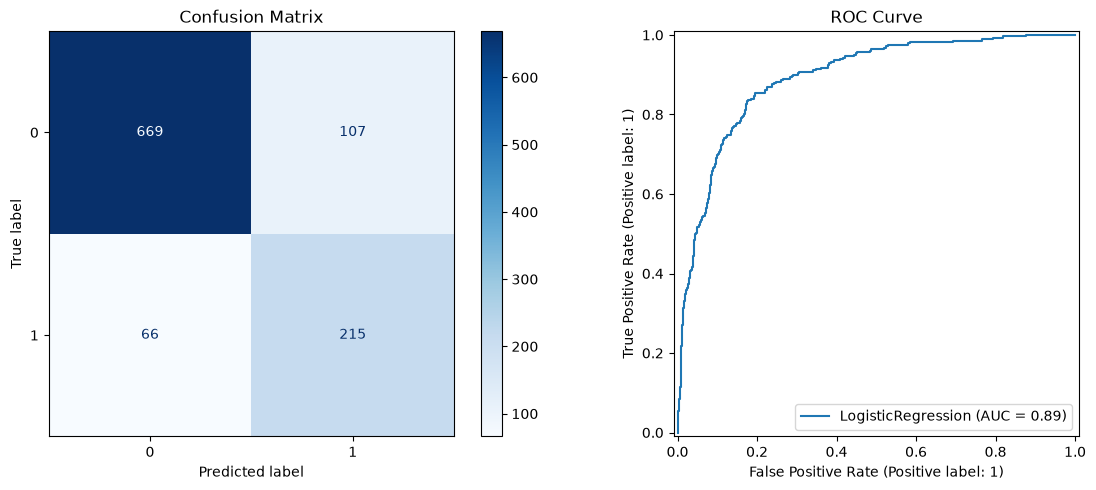

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.91      0.89       776
           1       0.72      0.64      0.68       281

    accuracy                           0.84      1057
   macro avg       0.80      0.78      0.79      1057
weighted avg       0.83      0.84      0.84      1057



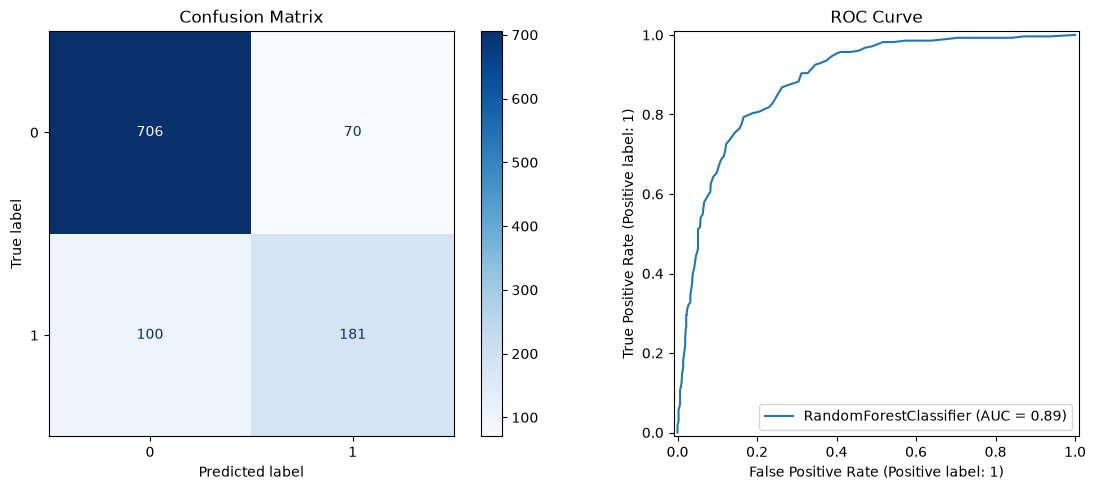

--- Gradient Boosting Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       776
           1       0.70      0.67      0.69       281

    accuracy                           0.84      1057
   macro avg       0.79      0.78      0.79      1057
weighted avg       0.84      0.84      0.84      1057



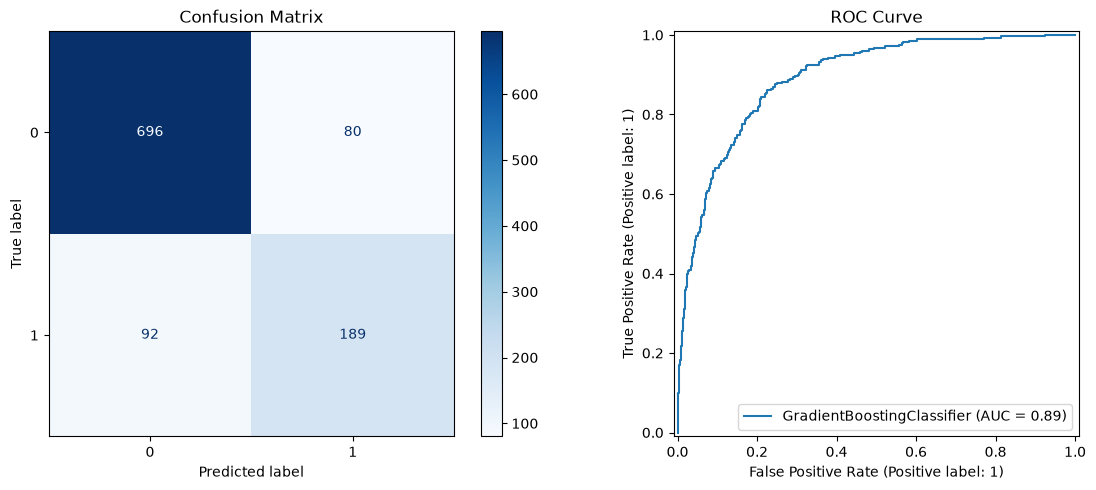

--- Lightgbm Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.92      0.90       776
           1       0.75      0.68      0.71       281

    accuracy                           0.85      1057
   macro avg       0.82      0.80      0.81      1057
weighted avg       0.85      0.85      0.85      1057



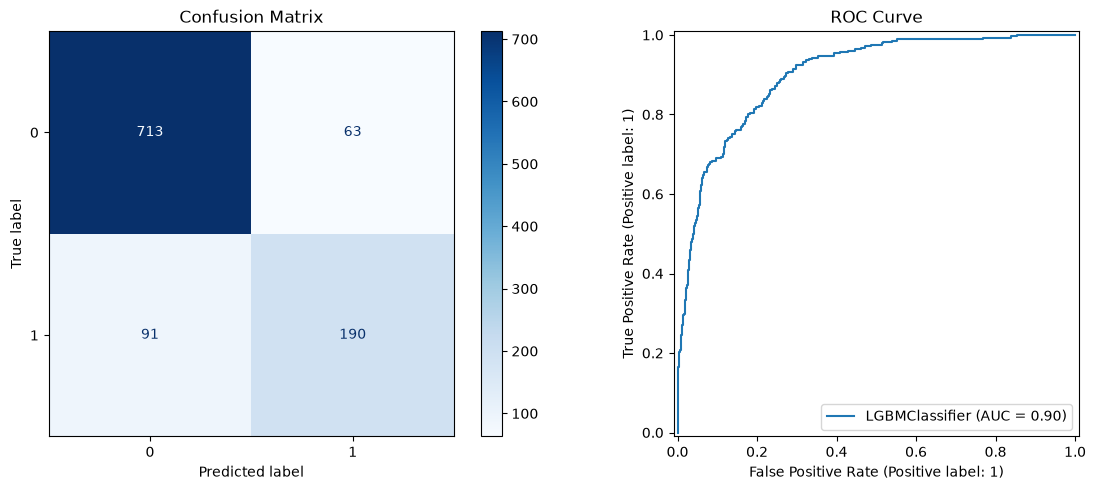

--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       776
           1       0.74      0.64      0.69       281

    accuracy                           0.85      1057
   macro avg       0.81      0.78      0.79      1057
weighted avg       0.84      0.85      0.84      1057



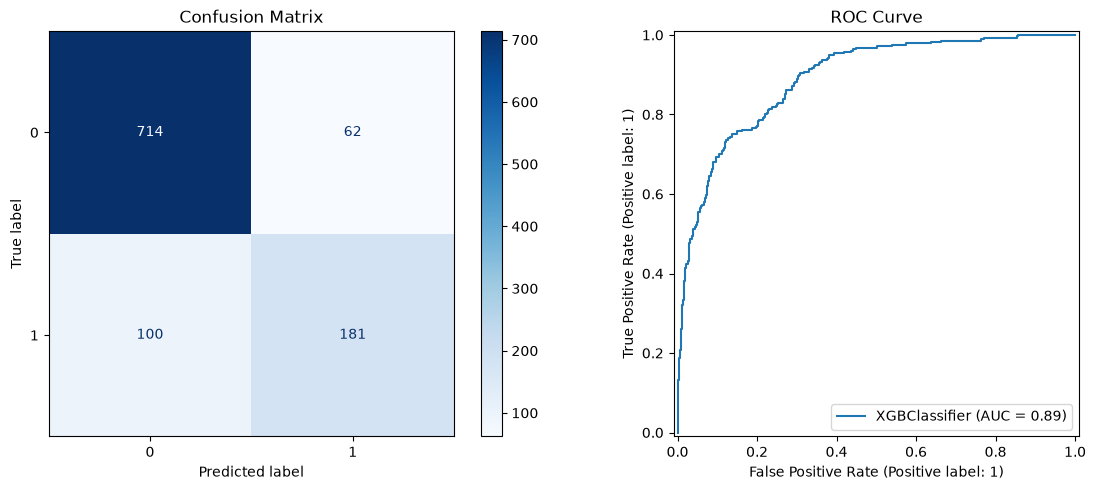

--- CatBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       776
           1       0.74      0.66      0.70       281

    accuracy                           0.85      1057
   macro avg       0.81      0.79      0.80      1057
weighted avg       0.84      0.85      0.85      1057



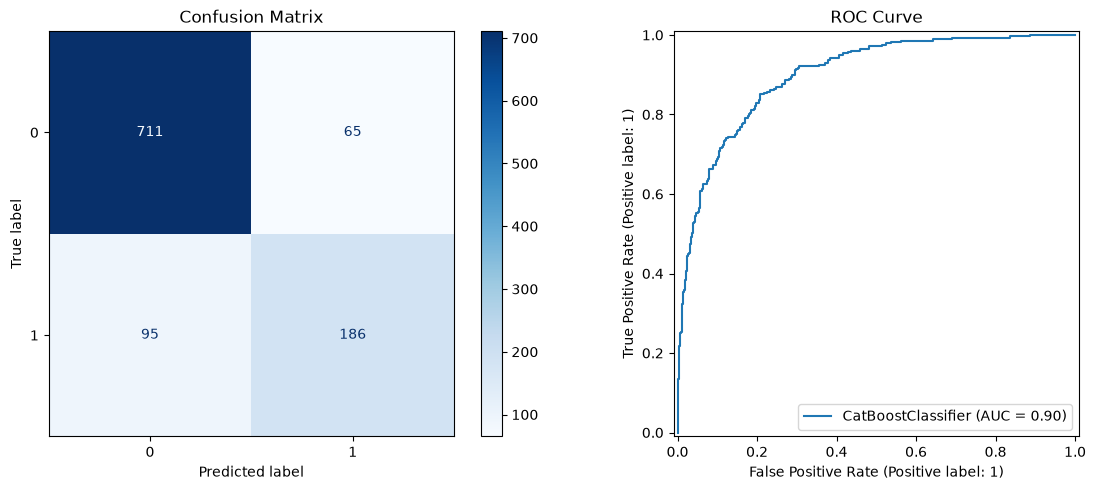

In [ ]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"--- {name} Classification Report ---")
    print(classification_report(y_test, y_pred))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap="Blues", ax=axes[0])
    axes[0].set_title("Confusion Matrix")

    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[1])
    axes[1].set_title("ROC Curve")

    plt.tight_layout()
    plt.show()